In [187]:
# Manipulation de données 
import pandas as pd 
import numpy as np

#Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns

#Prétraitement
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder

#Modeles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

#Evaluation 
from sklearn.metrics import (accuracy_score,classification_report, confusion_matrix, f1_score,precision_score,recall_score)

#Sauvegarde des artefacts
import joblib
import os
import warnings 
warnings.filterwarnings("ignore")

#Configuration de l'affichage 
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE) #permet de fixer la graine aleatoire (s'assurer qu'entre deux execution on obtient les meme resultat )

print("Librairies importées avec succès.")

Librairies importées avec succès.


In [188]:
data = pd.read_csv("C:/Users/solution info/Desktop/labo-ml/avc_project/data/healthcare-dataset-stroke-data.csv")
print(f"Dimensions du dataset : {data.shape[0]} lignes x {data.shape[1]} colonnes")
data.head()

Dimensions du dataset : 5110 lignes x 12 colonnes


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [189]:
#Q1 : Quelle est la structure général du fichier
print(f"Dimension du dataset : {data.shape}")
data.info()

Dimension du dataset : (5110, 12)
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


In [190]:
#Q1.2 : Quels sont les valeurs uniques pour chaque variable categorielle ?
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols : 
    print(f"{col} - Valeurs uniques : {data[col].unique()}")

gender - Valeurs uniques : <ArrowStringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
ever_married - Valeurs uniques : <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
work_type - Valeurs uniques : <ArrowStringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
Residence_type - Valeurs uniques : <ArrowStringArray>
['Urban', 'Rural']
Length: 2, dtype: str
smoking_status - Valeurs uniques : <ArrowStringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str


### Frouille de données 

In [191]:
#Q2.1 : Où et combien de valeur manquantes sont présentes dans le dataset
missing = data.isnull().sum()
missing_pct = ((missing / len(data)) * 100).round(2)
pd.DataFrame({"n_manquants" : missing, "%" : missing_pct}).query("n_manquants > 0")

,n_manquants,%
bmi,201,3.93


In [192]:
#Q2.2 : Le dataset contient-il des doublons ?
print(f"Lignes dupliquées hors (id) : {data.drop(columns=['id']).duplicated().sum()}")

Lignes dupliquées hors (id) : 0


In [193]:
#Q2.3 = Y a-t-il des valeurs aberantes dans les variables numériques ? Si oui , lesquelles et combien 
num_cols = data.select_dtypes(include=["int64", "float64"]).columns

data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [194]:
# definir une fonction pour detecter les outliers 
def detect_outliers(col):
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    borne_inf, borne_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers =  ((data[col]< borne_inf)| (data[col]> borne_sup)).sum()
    return outliers
for col in num_cols.drop("id"):
    outliers = detect_outliers(col)
    print(f"{col} - Nombre de valeurs aberrantes : {outliers}")

age - Nombre de valeurs aberrantes : 0
hypertension - Nombre de valeurs aberrantes : 498
heart_disease - Nombre de valeurs aberrantes : 276
avg_glucose_level - Nombre de valeurs aberrantes : 627
bmi - Nombre de valeurs aberrantes : 110
stroke - Nombre de valeurs aberrantes : 249


In [195]:
#Q2.4 les catégories déclarées sont - elles toutes exploitables statistiquement ?
print(data["gender"].value_counts()) # la fonction value_counts() affiche pour chaque colonne catégorielle les différentes classes et leurs effectifs
print(data["work_type"].value_counts())
print(data["smoking_status"].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


In [196]:
#Q2.5 la variable cible est-elle equilibrée ? Si non , quel est le dèséquilibre ?
data["stroke"].value_counts(normalize=True)*100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

### Traitement des problèmes identifiés

In [197]:
df = data.copy()

In [198]:
#Q3.1 : Comment traiter les valeurs manquantes dans la variables bmi ?
# Remplacement des valeurs manquantes par la mediane 
df["bmi"] = df["bmi"].fillna(df["bmi"].median())
print(f"Nombre de valeurs manquantes après traitement : {df['bmi'].isnull().sum()}")

Nombre de valeurs manquantes après traitement : 0


In [199]:
from scipy.stats.mstats import winsorize

#winsorisation de la variable age pour reduire l'impact des valeurs abérrantes
df["bmi"] = np.array(winsorize(df["bmi"], limits=[0.01, 0.01])) # le parametre limits
df["avg_glucose_level"] = np.array(winsorize(df["avg_glucose_level"], limits=[0.01, 0.01]))

In [200]:
#Q3;3 : Comment corriger les variables catégorielles codées numériquement ?
df["hypertension"] = df["hypertension"].astype("category")
df["heart_disease"] = df["heart_disease"].astype("category")
df["stroke"] = df["stroke"].astype("category")

In [201]:
#Q3.4 : Que faire de la categorie "orther" dans la variable gender ?
nb_other = (df["gender"] == "Other").sum()
if nb_other < 10:
    df = df[df["gender"] != "Other"].copy()
print(f"Ligne rétirées : {nb_other}")

Ligne rétirées : 1


## Analyse exploration et visualisation pertinentes 

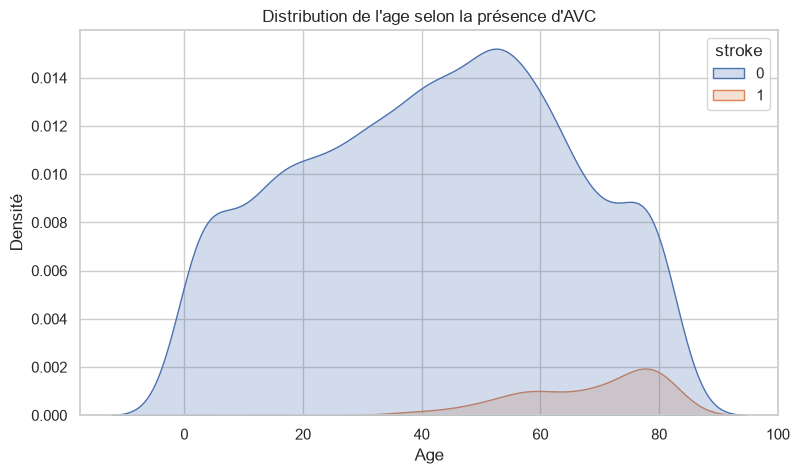

In [202]:
#Q4.1 : Comment la distribution de l'age de compare-t-elle entre les patients avec et sans AVC ?
sns.kdeplot(data=df, x="age", hue="stroke", fill=True)
plt.title("Distribution de l'age selon la présence d'AVC")
plt.xlabel("Age")
plt.ylabel("Densité")
plt.show()

Text(0.5, 1.0, "Taux d'AVC par tranche d'âge")

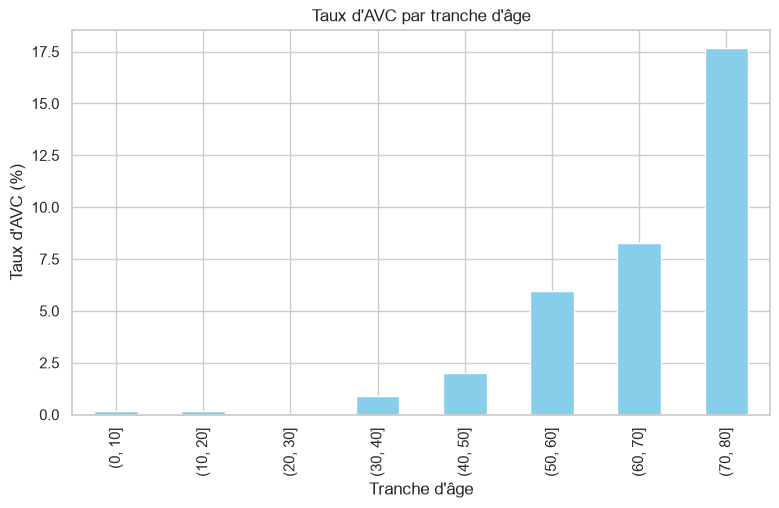

In [203]:
#Q4.2 Le taux d'AVC augmente-t-il avec l'age  de facon régulière ou par parliers?
df["age_bin"] = pd.cut(df["age"], bins=range(0, 90, 10))

taux = df.groupby("age_bin", observed=True)["stroke"].apply(lambda x: (x==1).mean() * 100)
taux.plot(kind="bar", color="skyblue")
plt.ylabel("Taux d'AVC (%)")
plt.xlabel("Tranche d'âge")
plt.title("Taux d'AVC par tranche d'âge")

<Axes: >

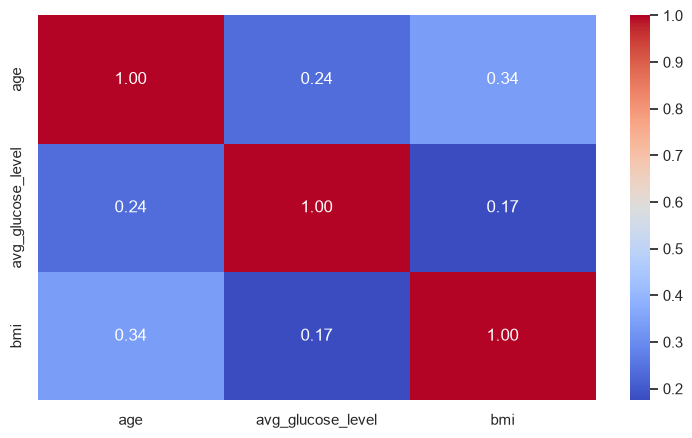

In [204]:
#Q4.3 : Existe t-il une correlation entre les variables numériques ?
cor = df[["age", "avg_glucose_level", "bmi"]].corr()
sns.heatmap(cor, annot=True, cmap="coolwarm", fmt=".2f") 

### Préparation 

### Sélection des variables et encodage

In [205]:
#Q5.1 Comment separer les variables explicatives et la cible ?
X = df.drop(columns=["stroke", "id","age_bin"])
y = df["stroke"]

In [206]:
ordinal_cols = ["smoking_status"]
cat_cols = ["gender", "ever_married", "work_type", "Residence_type"]
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X[ordinal_cols] = OrdinalEncoder().fit_transform(X[ordinal_cols])

# Prépartion 

### division de mon dataset 

In [207]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Gestion du deséquilibre des classes 

In [208]:
# Q7.1 Comment reéquilibrer le train sans provoquer de fuite de données vers le test ?
from imblearn.combine import SMOTEENN

smote_enn= SMOTEENN(random_state=RANDOM_STATE)
xtrain_res, ytrain_res = smote_enn.fit_resample(xtrain, ytrain)

print(f"Avant : {ytrain.value_counts().to_dict()}")
print(f"Après : {ytrain_res.value_counts().to_dict()}")

Avant : {0: 3888, 1: 199}
Après : {1: 3647, 0: 2959}


In [209]:
encodeur_ordinal = OrdinalEncoder()

In [210]:
# Mise en échelle 
noms_features = xtrain_res.columns  # xtrain_res, pas xtrain

scaler = StandardScaler()
xtrain_scaled = pd.DataFrame(scaler.fit_transform(xtrain_res), columns=noms_features, index=xtrain_res.index)
xtest_scaled = pd.DataFrame(scaler.transform(xtest), columns=noms_features, index=xtest.index)

xtrain_scaled.describe().T[["mean", "std"]].head()

,mean,std
age,-2.065156e-16,1.000076
hypertension,4.341678e-17,1.000095
heart_disease,1.544378e-17,1.000091
avg_glucose_level,-2.581445e-16,1.000076
bmi,-2.581445e-17,1.000076


In [211]:
from sklearn.impute import SimpleImputer

# --- Sécurité anti-NaN (au cas où) ---
imputer = SimpleImputer(strategy="median")
xtrain_res = pd.DataFrame(imputer.fit_transform(xtrain_res), columns=xtrain_res.columns, index=xtrain_res.index)
xtest = pd.DataFrame(imputer.transform(xtest), columns=xtest.columns, index=xtest.index)

# --- Standardisation ---
scaler = StandardScaler()
xtrain_scaled = pd.DataFrame(scaler.fit_transform(xtrain_res), columns=xtrain_res.columns, index=xtrain_res.index)
xtest_scaled = pd.DataFrame(scaler.transform(xtest), columns=xtest.columns, index=xtest.index)

ytrain_res = ytrain_res.astype(int)
ytest = ytest.astype(int)

# --- Modèles ---
modeles = {
    "Régression logistique": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Arbre de Décision": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=RANDOM_STATE, probability=True),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
}

resultats = []

for nom, modele in modeles.items():
    modele.fit(xtrain_scaled, ytrain_res)
    ypred = modele.predict(xtest_scaled)

    acc = accuracy_score(ytest, ypred)
    f1 = f1_score(ytest, ypred, average="macro")
    precision = precision_score(ytest, ypred, average="macro", zero_division=0)
    recall = recall_score(ytest, ypred)  # recall de la classe AVC (1) uniquement

    cv_scores = cross_val_score(modele, xtrain_scaled, ytrain_res, cv=5, scoring="recall")

    resultats.append({
        "Modèle": nom,
        "Accuracy (test)": acc,
        "F1-score (macro)": f1,
        "Précision (macro)": precision,
        "Rappel (test, classe AVC)": recall,
        "Rappel cv (moyenne)": cv_scores.mean(),
        "Rappel cv (écart-type)": cv_scores.std(),
    })

    print(f"--- {nom} ---")
    print(f"Rappel (test) : {recall:.4f} | Rappel cv (5-fold) : {cv_scores.mean():.4f} (+/-{cv_scores.std():.4f})")



--- Régression logistique ---
Rappel (test) : 0.6800 | Rappel cv (5-fold) : 0.9134 (+/-0.0267)
--- Arbre de Décision ---
Rappel (test) : 0.3200 | Rappel cv (5-fold) : 0.9575 (+/-0.0426)
--- Random Forest ---
Rappel (test) : 0.4000 | Rappel cv (5-fold) : 0.9718 (+/-0.0490)
--- KNN ---
Rappel (test) : 0.5600 | Rappel cv (5-fold) : 0.9671 (+/-0.0378)
--- SVM ---
Rappel (test) : 0.5400 | Rappel cv (5-fold) : 0.9419 (+/-0.0370)
--- Gradient Boosting ---
Rappel (test) : 0.4800 | Rappel cv (5-fold) : 0.9608 (+/-0.0469)
--- XGBoost ---
Rappel (test) : 0.4200 | Rappel cv (5-fold) : 0.9764 (+/-0.0444)


In [212]:
df_resultats = pd.DataFrame(resultats).sort_values(by="Rappel cv (moyenne)", ascending=False)
df_resultats

,Modèle,Accuracy (test),F1-score (macro),Précision (macro),"Rappel (test, classe AVC)",Rappel cv (moyenne),Rappel cv (écart-type)
6,XGBoost,0.857143,0.572370,0.559684,0.42,0.976437,0.044408
2,Random Forest,0.871820,0.581988,0.565996,0.40,0.971777,0.048967
3,KNN,0.782779,0.537866,0.547550,0.56,0.967112,0.037829
5,Gradient Boosting,0.814090,0.548238,0.548242,0.48,0.960810,0.046895
1,Arbre de Décision,0.827789,0.528993,0.530957,0.32,0.957517,0.042603
4,SVM,0.768102,0.525185,0.541292,0.54,0.941885,0.036961
0,Régression logistique,0.742661,0.525953,0.549702,0.68,0.913363,0.026741


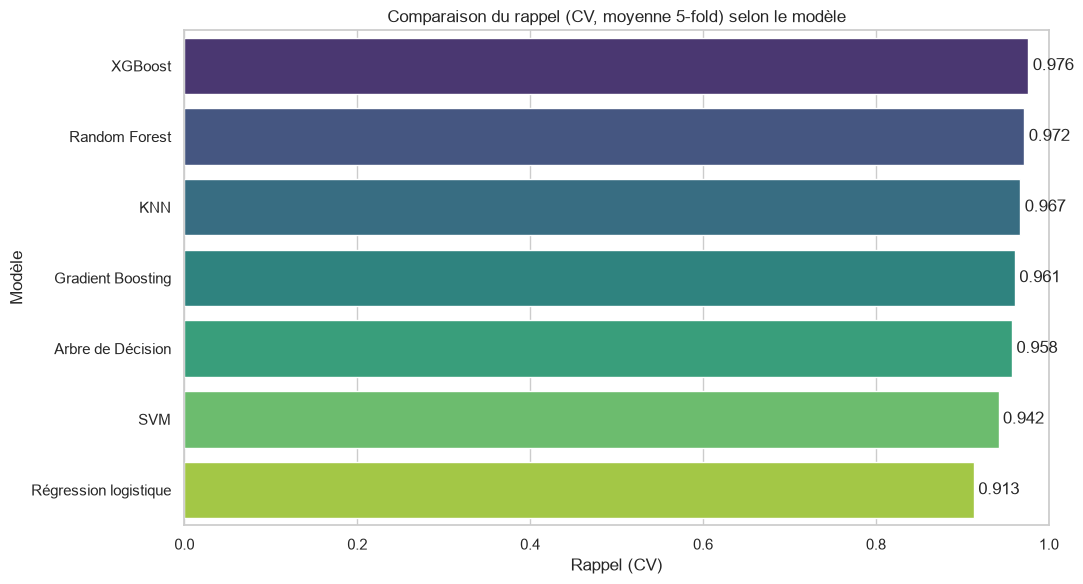

In [213]:
df_plot = df_resultats.sort_values(by="Rappel cv (moyenne)", ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(data=df_plot, x="Rappel cv (moyenne)", y="Modèle", hue="Modèle", palette="viridis", legend=False)
plt.title("Comparaison du rappel (CV, moyenne 5-fold) selon le modèle")
plt.xlabel("Rappel (CV)")
plt.xlim(0, 1)

for i, valeur in enumerate(df_plot["Rappel cv (moyenne)"]):
    plt.text(valeur + 0.005, i, f"{valeur:.3f}", va="center")

plt.tight_layout()
plt.show()

In [214]:
meilleur_nom = df_resultats.iloc[0]["Modèle"]
meilleur_modele_baseline = modeles[meilleur_nom]
ypred_meilleur = meilleur_modele_baseline.predict(xtest_scaled)

print(f"Meilleur modèle (baseline) : {meilleur_nom}\n")
print(classification_report(ytest, ypred_meilleur, target_names=["Pas d'AVC", "AVC"]))

Meilleur modèle (baseline) : XGBoost

              precision    recall  f1-score   support

   Pas d'AVC       0.97      0.88      0.92       972
         AVC       0.15      0.42      0.22        50

    accuracy                           0.86      1022
   macro avg       0.56      0.65      0.57      1022
weighted avg       0.93      0.86      0.89      1022



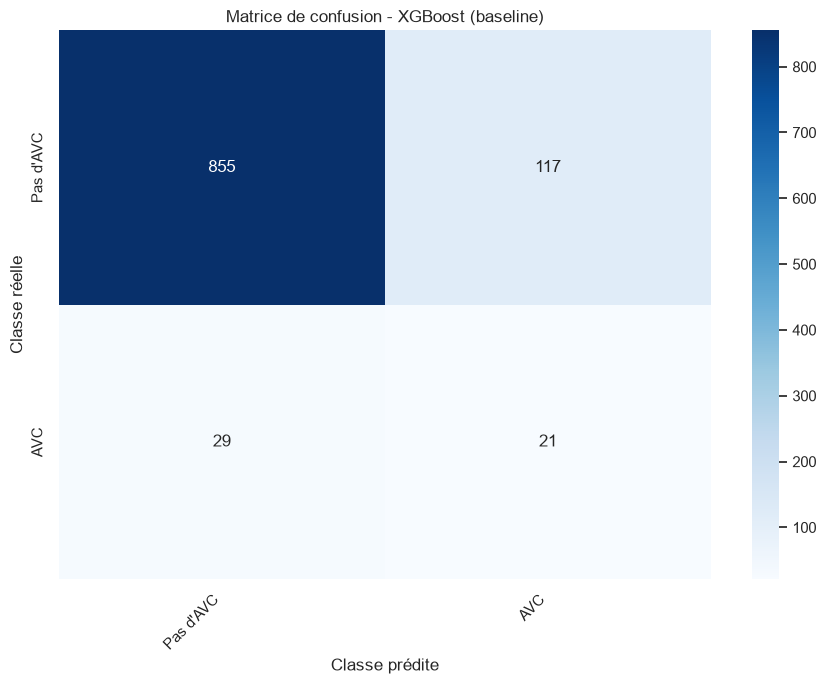

In [215]:
plt.figure(figsize=(9, 7))
matrice_confusion = confusion_matrix(ytest, ypred_meilleur)
sns.heatmap(matrice_confusion, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pas d'AVC", "AVC"], yticklabels=["Pas d'AVC", "AVC"])
plt.title(f"Matrice de confusion - {meilleur_nom} (baseline)")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [216]:
top_2_modeles= df_resultats["Modèle"].iloc[:2].tolist()
print("Modèles sélectionnés pour l'optimisation :",top_2_modeles)

Modèles sélectionnés pour l'optimisation : ['XGBoost', 'Random Forest']


In [217]:
grilles_hyperparametres = {
    "Random Forest": {
        "modele": RandomForestClassifier(random_state=RANDOM_STATE),
        "grille": {
            "n_estimators": [100, 200],
            "max_depth": [None, 15],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
            "class_weight": ["balanced", None],
        },
    },
    "Gradient Boosting": {
        "modele": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "grille": {
            "n_estimators": [100, 150],
            "max_depth": [2, 3],
            "learning_rate": [0.1, 0.2],
        },
    },
    "Arbre de Décision": {
        "modele": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "grille": {
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 5, 10],
            "criterion": ["gini", "entropy"],
            "class_weight": ["balanced", None],
        },
    },
    "SVM": {
        "modele": SVC(random_state=RANDOM_STATE, probability=True),
        "grille": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf", "linear"],
            "gamma": ["scale", "auto"],
            "class_weight": ["balanced", None],
        },
    },
    "Régression logistique": {
        "modele": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "grille": {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["lbfgs", "liblinear"],
            "class_weight": ["balanced", None],
        },
    },
    "KNN": {
        "modele": KNeighborsClassifier(),
        "grille": {
            "n_neighbors": [3, 5, 7, 9, 11],
            "weights": ["uniform", "distance"],
        },
    },
}

cv_strategie = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
modeles_optimises = {}

cv_strategie = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
modeles_optimises = {}

for nom in top_2_modeles:
    if nom not in grilles_hyperparametres:
        print(f"\n=== {nom} ignoré (pas de grille définie) ===")
        continue

    config = grilles_hyperparametres[nom]
    print(f"\n=== Optimisation de : {nom} ===")

    recherche = GridSearchCV(
        estimator=config["modele"],
        param_grid=config["grille"],
        cv=cv_strategie,
        scoring="recall",
        n_jobs=-1,
        verbose=0,
    )
    recherche.fit(xtrain_scaled, ytrain_res)

    print(f"Meilleurs hyperparamètres : {recherche.best_params_}")
    print(f"Meilleur rappel en validation : {recherche.best_score_:.4f}")

    modeles_optimises[nom] = recherche.best_estimator_

print(f"\nModèles optimisés disponibles : {list(modeles_optimises.keys())}")


=== XGBoost ignoré (pas de grille définie) ===

=== Optimisation de : Random Forest ===
Meilleurs hyperparamètres : {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Meilleur rappel en validation : 0.9811

Modèles optimisés disponibles : ['Random Forest']


In [218]:
resultats_optimises = []

for nom, modele in modeles_optimises.items():
    ypred = modele.predict(xtest_scaled)
    recall = recall_score(ytest, ypred)
    precision = precision_score(ytest, ypred, zero_division=0)
    f1 = f1_score(ytest, ypred)
    acc = accuracy_score(ytest, ypred)

    resultats_optimises.append({
        "Modèle": nom,
        "Rappel (test)": recall,
        "Précision (test)": precision,
        "F1-score (test)": f1,
        "Accuracy (test)": acc,
    })

    print(f"--- {nom} (optimisé) ---")
    print(f"Rappel : {recall:.4f} | Précision : {precision:.4f} | F1 : {f1:.4f}")

df_resultats_optimises = pd.DataFrame(resultats_optimises).sort_values(by="Rappel (test)", ascending=False)
df_resultats_optimises

--- Random Forest (optimisé) ---
Rappel : 0.4400 | Précision : 0.1447 | F1 : 0.2178


,Modèle,Rappel (test),Précision (test),F1-score (test),Accuracy (test)
0,Random Forest,0.44,0.144737,0.217822,0.845401


In [219]:
# Sélection du modèle final (le meilleur après optimisation)
nom_modele_final = df_resultats_optimises.iloc[0]["Modèle"]
modele_final = modeles_optimises[nom_modele_final]
ypred_final = modele_final.predict(xtest_scaled)

print(f"Modèle final retenu : {nom_modele_final}")
print(f"Rappel final (test) : {recall_score(ytest, ypred_final):.4f}")
print(f"Accuracy finale (test) : {accuracy_score(ytest, ypred_final):.4f}")

Modèle final retenu : Random Forest
Rappel final (test) : 0.4400
Accuracy finale (test) : 0.8454


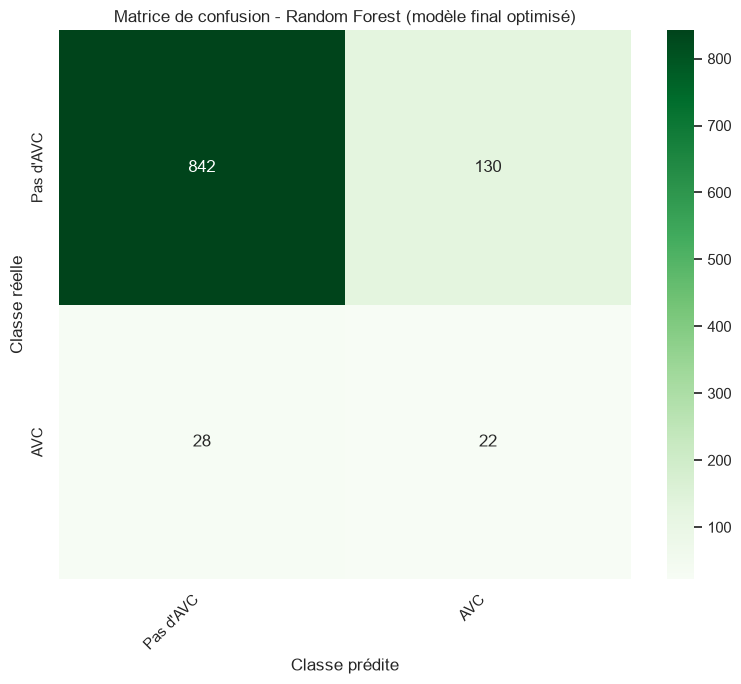

In [220]:
plt.figure(figsize=(8, 7))
matrice_confusion_finale = confusion_matrix(ytest, ypred_final)
sns.heatmap(matrice_confusion_finale, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pas d'AVC", "AVC"], yticklabels=["Pas d'AVC", "AVC"])
plt.title(f"Matrice de confusion - {nom_modele_final} (modèle final optimisé)")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

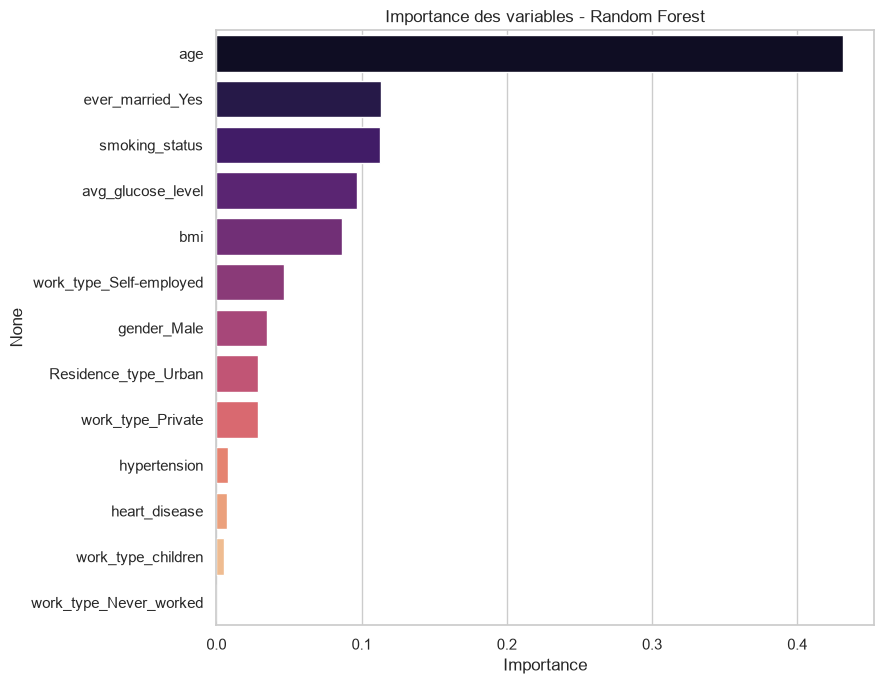

age                        0.431277
ever_married_Yes           0.113071
smoking_status             0.112537
avg_glucose_level          0.096584
bmi                        0.086295
work_type_Self-employed    0.046872
gender_Male                0.034630
Residence_type_Urban       0.028877
work_type_Private          0.028654
hypertension               0.008231
heart_disease              0.007423
work_type_children         0.005488
work_type_Never_worked     0.000060
dtype: float64


In [221]:
# Importance des variables (si le modèle final le permet)
noms_features = xtrain_res.columns

if hasattr(modele_final, "feature_importances_"):
    importances = pd.Series(modele_final.feature_importances_, index=noms_features)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(9, 7))
    sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="magma", legend=False)
    plt.title(f"Importance des variables - {nom_modele_final}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print(importances)

elif hasattr(modele_final, "coef_"):
    # Cas de la Régression logistique / SVM linéaire : pas de feature_importances_,
    # mais les coefficients jouent un rôle équivalent (en valeur absolue)
    importances = pd.Series(modele_final.coef_[0], index=noms_features)
    importances = importances.reindex(importances.abs().sort_values(ascending=False).index)

    plt.figure(figsize=(9, 7))
    colors = ["crimson" if v < 0 else "steelblue" for v in importances.values]
    sns.barplot(x=importances.values, y=importances.index, palette=colors)
    plt.title(f"Coefficients des variables - {nom_modele_final}")
    plt.xlabel("Coefficient")
    plt.axvline(x=0, color="black", linewidth=0.8)
    plt.tight_layout()
    plt.show()

    print(importances)

else:
    print("Le modèle final ne fournit pas nativement d'importance des variables.")

In [223]:
dossier_artefacts = "../model_artifacts"
os.makedirs(dossier_artefacts, exist_ok=True)

joblib.dump(modele_final, os.path.join(dossier_artefacts, "modele_final.joblib"))
joblib.dump(scaler, os.path.join(dossier_artefacts, "scaler.joblib"))
joblib.dump(encodeur_ordinal, os.path.join(dossier_artefacts, "encodeur_ordinal.joblib"))
joblib.dump(list(noms_features), os.path.join(dossier_artefacts, "noms_features.joblib"))

print("Artefacts sauvegardés dans le dossier :", dossier_artefacts)
print(os.listdir(dossier_artefacts))

Artefacts sauvegardés dans le dossier : ../model_artifacts
['encodeur_ordinal.joblib', 'modele_final.joblib', 'noms_features.joblib', 'scaler.joblib']


In [224]:

modele_recharge = joblib.load(os.path.join(dossier_artefacts, "modele_final.joblib"))
scaler_recharge = joblib.load(os.path.join(dossier_artefacts, "scaler.joblib"))

echantillon = xtest.iloc[:5]
echantillon_scaled = scaler_recharge.transform(echantillon)
predictions_rechargees = modele_recharge.predict(echantillon_scaled)

labels = {0: "Pas d'AVC", 1: "AVC"}
classes_predictes = [labels[p] for p in predictions_rechargees]
classes_reelles = [labels[r] for r in ytest.iloc[:5].values]

print("Prédiction du modèle rechargé sur 5 exemples du jeu de test :")
print(classes_predictes)
print("\nClasses réelles correspondantes :")
print(classes_reelles)


Prédiction du modèle rechargé sur 5 exemples du jeu de test :
["Pas d'AVC", "Pas d'AVC", "Pas d'AVC", "Pas d'AVC", "Pas d'AVC"]

Classes réelles correspondantes :
["Pas d'AVC", "Pas d'AVC", "Pas d'AVC", "Pas d'AVC", "Pas d'AVC"]
